# Задача 7. CpG islands детектор

**Цель:** реализовать алгоритм поиска CpG островков по критериям Гардинера-Гардена.

In [3]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

In [4]:
record   = SeqIO.read('chr1.fa', 'fasta')
sequence = str(record.seq[3_000_000 : 3_100_000]).upper() #беру не первые, потому что так почти все NNN

In [5]:
def compute_cpg_ratio(window):
    n = len(window)
    if n < 2:
        return None

    count_c  = window.count('C')
    count_g  = window.count('G')
    count_cg = sum(
        1 for i in range(n - 1)
        if window[i] == 'C' and window[i+1] == 'G'
    )

    p_c  = count_c / n
    p_g  = count_g / n
    p_cg = count_cg / (n - 1)

    r_cg       = p_cg / (p_c * p_g) if (p_c > 0 and p_g > 0) else 0.0
    gc_percent = (count_c + count_g) / n * 100

    return {'R_CG': r_cg, 'GC_percent': gc_percent}

In [8]:
def scan_cpg_islands(sequence, window_size=200, step=10,
                     r_threshold=0.6, gc_threshold=50.0): #функция 
    positions, r_values, gc_values = [], [], []
    in_island    = False
    island_start = 0
    islands      = []

    for i in range(0, len(sequence) - window_size + 1, step):
        window  = sequence[i : i + window_size]
        metrics = compute_cpg_ratio(window)

        positions.append(i + window_size // 2)
        r_values.append(metrics['R_CG'])
        gc_values.append(metrics['GC_percent'])

        is_island = (metrics['R_CG'] > r_threshold and
                     metrics['GC_percent'] > gc_threshold)

        if is_island and not in_island:
            in_island    = True
            island_start = i
        elif not is_island and in_island:
            in_island = False
            islands.append((island_start, i + window_size))

    if in_island:
        islands.append((island_start, len(sequence)))

    return np.array(positions), np.array(r_values), np.array(gc_values), islands

In [10]:
def plot_cpg_islands(positions, r_values, gc_values, islands, region_start):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(
        f'CpG Islands — chr1 позиции {region_start:,}–{region_start+100_000:,}\n'
        'Критерии Гардинера-Гардена: R(CG) > 0.6 и GC% > 50%',
        fontsize=13, fontweight='bold'
    )

    genome_pos = positions + region_start

    ax1.plot(genome_pos, r_values,
             color='steelblue', linewidth=0.7, alpha=0.85, label='R(CG)')
    ax1.axhline(y=0.6, color='crimson', linewidth=1.5,
                linestyle='--', label='Порог 0.6')

    for idx, (start, end) in enumerate(islands):
        lbl = f'CpG острова (n={len(islands)})' if idx == 0 else '_'
        ax1.axvspan(start + region_start, end + region_start,
                    alpha=0.3, color='limegreen', label=lbl)
        ax2.axvspan(start + region_start, end + region_start,
                    alpha=0.3, color='limegreen')

    ax1.set_ylabel('R(CG)', fontsize=11)
    ax1.set_ylim(0, max(float(r_values.max()) * 1.1, 1.0))
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2.plot(genome_pos, gc_values,
             color='darkorange', linewidth=0.7, alpha=0.85, label='GC%')
    ax2.axhline(y=50, color='crimson', linewidth=1.5,
                linestyle='--', label='Порог 50%')
    ax2.set_ylabel('GC%', fontsize=11)
    ax2.set_xlabel('Позиция в геноме (нт)', fontsize=11)
    ax2.set_ylim(0, 100)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('cpg_islands.png', dpi=150, bbox_inches='tight')
    plt.show()

Найдено CpG островков: 69
#     Start (геном)  End (геном)   Длина    R(CG)      GC%
1         3,000,370    3,000,580     210    0.548    54.3%
2         3,000,410    3,000,620     210    0.524    53.2%
3         3,001,700    3,001,920     220    0.658    58.9%
4         3,001,740    3,002,300     560    0.748    60.8%
5         3,003,840    3,004,060     220    0.488    61.8%
6         3,011,410    3,011,620     210    0.483    52.7%
7         3,011,820    3,012,210     390    0.720    57.7%
8         3,012,020    3,012,260     240    0.813    50.3%
9         3,012,200    3,012,590     390    0.761    53.0%
10        3,012,410    3,012,910     500    0.672    63.3%
11        3,014,510    3,014,720     210    0.571    49.9%
12        3,018,110    3,018,340     230    0.463    60.7%
13        3,020,120    3,020,330     210    0.612    50.5%
14        3,020,160    3,020,450     290    0.550    53.9%
15        3,021,900    3,022,280     380    0.531    62.6%
16        3,022,270    3,022,5

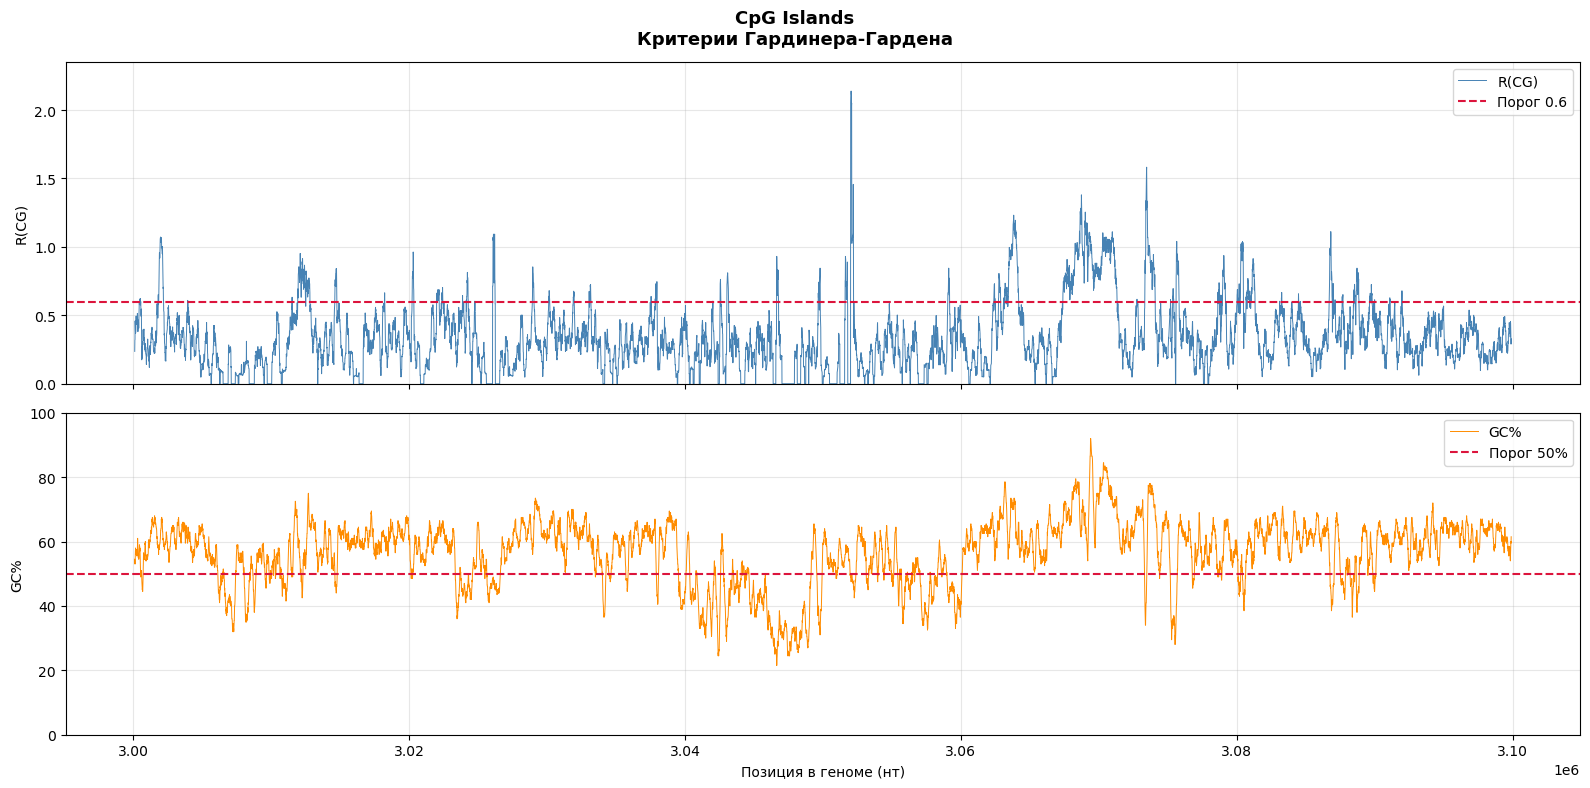

In [19]:
print(f"Найдено CpG островков: {len(islands)}")
print(f"{'#':<4} {'Start (геном)':>14} {'End (геном)':>12} {'Длина':>7} {'R(CG)':>8} {'GC%':>8}")
for idx, (start, end) in enumerate(islands, 1):
    mask   = (positions >= start) & (positions <= end)
    avg_r  = float(r_values[mask].mean())  if mask.any() else 0.0
    avg_gc = float(gc_values[mask].mean()) if mask.any() else 0.0
    print(f"{idx:<4} {start+3_000_000:>14,} {end+3_000_000:>12,} "
          f"{end-start:>7} {avg_r:>8.3f} {avg_gc:>7.1f}%")

genome_pos = positions + 3_000_000

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('CpG Islands\nКритерии Гардинера-Гардена', fontsize=13, fontweight='bold')

ax1.plot(genome_pos, r_values, color='steelblue', linewidth=0.7, label='R(CG)')
ax1.axhline(y=0.6, color='crimson', linewidth=1.5, linestyle='--', label='Порог 0.6')
ax2.plot(genome_pos, gc_values, color='darkorange', linewidth=0.7, label='GC%')
ax2.axhline(y=50, color='crimson', linewidth=1.5, linestyle='--', label='Порог 50%')

ax1.set_ylabel('R(CG)'); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_ylim(0, max(float(r_values.max()) * 1.1, 1.0))
ax2.set_ylabel('GC%'); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_xlabel('Позиция в геноме (нт)'); ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()